### Domain Transformation

This notebook compares the Phase Shift and HRLRT methods for domain transformation of seismic data.

--Still on going

In [1]:
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import time

def phase_shift_method(u_xt, t, x, freq_range=(5, 50), vel_range=(50, 800), 
                       n_vel=100, normalize=True):
    """
    Traditional Phase Shift method - this is the CORRECT reference.
    Works directly in frequency domain.
    """
    dt = np.mean(np.diff(t))
    fmin, fmax = freq_range
    vrmin, vrmax = vel_range[0], vel_range[1]
    vrinc = (vrmax - vrmin) / n_vel
    
    # FFT
    m, n = u_xt.shape
    np2 = (m - 1).bit_length()
    u = np.zeros((2**np2, n))
    u[0:m, 0:n] = u_xt
    
    U = np.fft.fft(u, axis=0)
    U = U[0:2**(np2-1)+1, :]
    
    # Frequency vector
    fnyq = 1 / (2 * dt)
    fvec = fnyq * np.arange(0, 2**(np2-1)+1) / (2**(np2-1))
    
    # Frequency range
    fmini = np.argmin(np.abs(fvec - fmin))
    fmaxi = np.argmin(np.abs(fvec - fmax))
    
    Vtrial = np.arange(vrmin, vrmax + vrinc, vrinc)
    fi = np.arange(fmini, fmaxi + 1)
    
    # Phase shift summation
    V = np.zeros((len(Vtrial), len(fi)), dtype=complex)
    
    for idx, i in enumerate(fi):
        keq = (2 * np.pi * fvec[i]) / Vtrial
        for j in range(n):
            e = np.exp(1j * keq * x[j])
            V[:, idx] += U[i, j] * e
    
    # Normalize
    if normalize:
        for im in range(V.shape[1]):
            max_val = np.max(np.abs(V[:, im]))
            if max_val > 0:
                V[:, im] = V[:, im] / max_val
            else:
                V[:, im] = 0.0
    
    ffi = fvec[fi]
    V_abs = np.abs(V)
    
    return ffi, Vtrial, V_abs

def HRLRT_frequency_domain(u_xt, t, x, freq_list, vel_range, n_vel=100, 
                           lam=0.001, n_iter=5, verbose=True):
    """
    HRLRT method that works DIRECTLY in frequency domain like Phase Shift.
    This is the correct approach.
    """
    dt = np.mean(np.diff(t))
    c_vals = np.linspace(vel_range[0], vel_range[1], n_vel)
    
    # FFT of input data
    m, n = u_xt.shape
    np2 = (m - 1).bit_length()
    u = np.zeros((2**np2, n))
    u[0:m, 0:n] = u_xt
    
    U_fft = np.fft.fft(u, axis=0)
    U_fft = U_fft[0:2**(np2-1)+1, :]
    
    # Frequency vector
    fnyq = 1 / (2 * dt)
    fvec = fnyq * np.arange(0, 2**(np2-1)+1) / (2**(np2-1))
    
    nf = len(freq_list)
    nc = len(c_vals)
    q_all = np.zeros((nf, nc), dtype=complex)
    
    if verbose:
        print(f"\nStarting HRLRT in frequency domain...")
        print(f"  Frequencies: {nf}")
        print(f"  Phase velocities: {nc}")
        t_start = time.time()
    
    # Process each frequency
    for k, freq in enumerate(freq_list):
        if verbose and (k % 10 == 0 or k == nf-1):
            progress = (k+1) / nf * 100
            print(f"  {k+1}/{nf} ({progress:.0f}%) - {freq:.1f} Hz")
        
        # Find closest frequency in FFT
        f_idx = np.argmin(np.abs(fvec - freq))
        
        # Get Fourier coefficients at this frequency
        U_f = U_fft[f_idx, :]  # (nx,) complex array
        
        # Build Linear Radon operator: L[i,j] = exp(-i*2*pi*f*x[i]/c[j])
        L = build_L_matrix(x, c_vals, freq)
        
        # Initial guess using simple summation
        q = (L.conj().T @ U_f)
        
        # Iterative HRLRT refinement
        for it in range(n_iter):
            # Model weights
            Wq = np.diag(1.0 / np.sqrt(np.abs(q) + 1e-12))
            
            # Data weights (single trace, so simpler)
            residual = L @ q - U_f
            Wr = 1.0 / (np.abs(residual) + 1e-12)
            Wr = np.diag(Wr)
            
            # Solve weighted least squares
            Wq_inv = np.linalg.inv(Wq)
            A = Wq_inv @ (L.conj().T @ Wr @ Wr @ L) @ Wq_inv + lam * np.eye(nc)
            b = L.conj().T @ Wr @ Wr @ U_f
            
            try:
                q = np.linalg.solve(A, b)
            except:
                q = np.linalg.lstsq(A, b, rcond=None)[0]
        
        q_all[k, :] = q
    
    A_all = np.abs(q_all)
    
    # Normalize each frequency
    for k in range(nf):
        max_val = np.max(A_all[k, :])
        if max_val > 0:
            A_all[k, :] = A_all[k, :] / max_val
    
    if verbose:
        print(f"\n✓ Complete! Total time: {time.time()-t_start:.1f}s")
    
    return A_all, freq_list, c_vals


def build_L_matrix(offset, c_vals, freq):
    """Build Linear Radon operator - vectorized."""
    x = offset[:, None]
    c = c_vals[None, :]
    return np.exp(-1j * 2 * np.pi * freq * (x / c))

def process_masw_hrlrt(u_xt, t, x, freq_range=(5, 50), vel_range=(100, 800),
                       n_freq=50, n_vel=200, lam=0.001, n_iter=5):
    """
    Process MASW data using HRLRT method (frequency domain version).
    """
    print("="*70)
    print("MASW DISPERSION ANALYSIS - HRLRT METHOD")
    print("="*70)
    
    # Preprocessing
    print("\nPreprocessing data...")
    u_processed = u_xt.copy()
    for ix in range(u_xt.shape[1]):
        trace = u_xt[:, ix]
        if np.std(trace) > 0:
            u_processed[:, ix] = trace / np.std(trace)
    
    # Taper
    taper_len = int(0.05 * len(t))
    taper = np.hanning(2 * taper_len)
    u_processed[:taper_len, :] *= taper[:taper_len, np.newaxis]
    u_processed[-taper_len:, :] *= taper[taper_len:, np.newaxis]
    print(f"  ✓ Normalized and tapered")
    
    # Setup parameters
    freq_list = np.linspace(freq_range[0], freq_range[1], n_freq)
    
    # Run HRLRT
    A_all, freq_out, c_vals = HRLRT_frequency_domain(
        u_processed, t, x, freq_list, vel_range, 
        n_vel=n_vel, lam=lam, n_iter=n_iter, verbose=True
    )
    
    # # Peak picking
    # max_idx = np.argmax(A_all, axis=1)
    # picked_velocities = c_vals[max_idx]
    return A_all, freq_out, c_vals

In [8]:
from obspy import read
import numpy as np

st = read(r"C:\Users\benin\orion\comgeo-things\data\synthetic_2.sgy")   # or .segy
# Convert to matrix
n_traces = len(st)
n_samples = st[0].stats.npts
u_xt = np.zeros((n_samples, n_traces))

for i, tr in enumerate(st):
    u_xt[:, i] = tr.data

t = np.arange(n_samples) * st[0].stats.delta  # time axis
x = np.arange(n_traces)
freq_range = (5, 30)
vel_range = (100, 800)
n_vel = 100

freq_ps, vel_ps, V_ps = phase_shift_method(u_xt, t, x, 
                            freq_range, vel_range, n_vel)

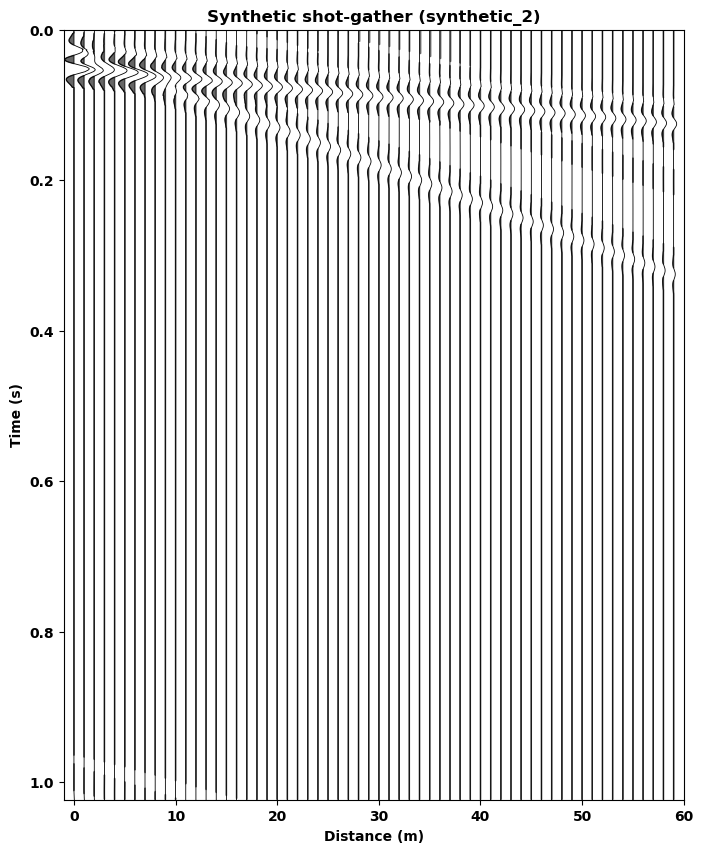

In [9]:
dx = 1.0
nx = 60
# Wiggle plot (filled for negative lobes) — vertical time axis
fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gain = 1.5 * dx  # horizontal scaling of wiggles
maxamp = np.max(np.abs(u_xt))
for ix in range(nx):
    trace = u_xt[:, ix] / (maxamp + 1e-12) * gain
    ax.plot(x[ix] + trace, t, color='k', linewidth=0.6)
    ax.fill_betweenx(t, x[ix], x[ix] + trace, where=(trace < 0), color='k', alpha=0.6)
ax.set_xlim(x.min()-dx, x.max()+dx)
ax.set_ylim(t.max(), t.min())
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Time (s)')
ax.set_title('Synthetic shot-gather (synthetic_2)')
plt.gca()
plt.show()

In [10]:
A_hrlrt, freq_hrlrt, vel_hrlrt = process_masw_hrlrt(
    u_xt, t, x, freq_range, vel_range,
    n_freq=100, n_vel=100, lam=0.001, n_iter=5
)

MASW DISPERSION ANALYSIS - HRLRT METHOD

Preprocessing data...
  ✓ Normalized and tapered

Starting HRLRT in frequency domain...
  Frequencies: 100
  Phase velocities: 100
  1/100 (1%) - 5.0 Hz
  11/100 (11%) - 7.5 Hz
  21/100 (21%) - 10.1 Hz
  31/100 (31%) - 12.6 Hz
  41/100 (41%) - 15.1 Hz
  51/100 (51%) - 17.6 Hz
  61/100 (61%) - 20.2 Hz
  71/100 (71%) - 22.7 Hz
  81/100 (81%) - 25.2 Hz
  91/100 (91%) - 27.7 Hz
  100/100 (100%) - 30.0 Hz

✓ Complete! Total time: 0.5s


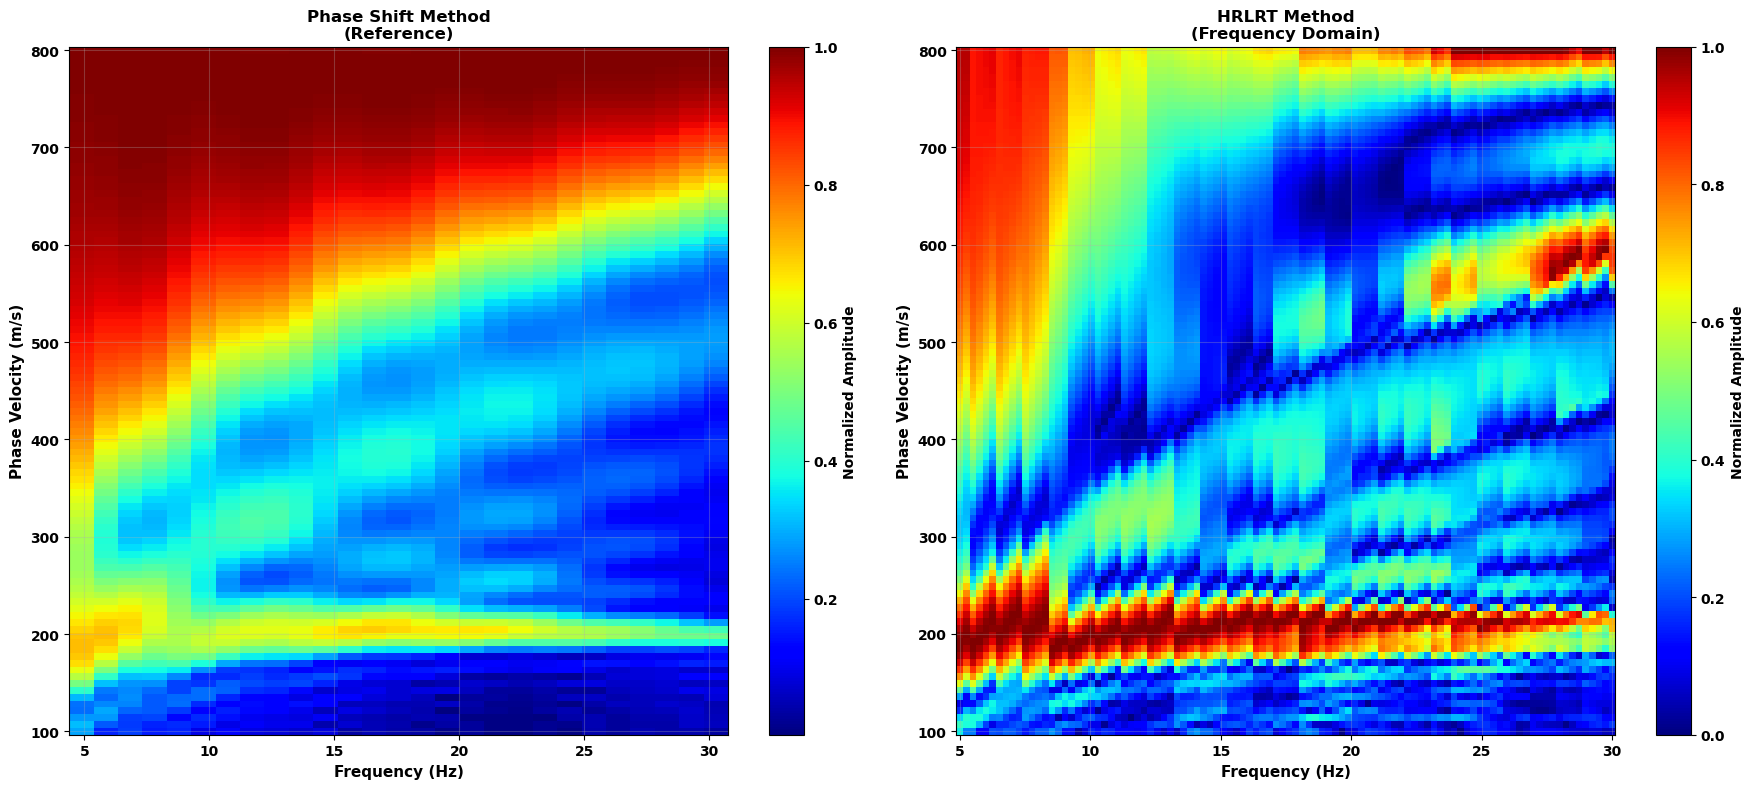

In [11]:
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Phase Shift
fgrid_ps, vgrid_ps = np.meshgrid(freq_ps, vel_ps)
im1 = axes[0].pcolormesh(fgrid_ps, vgrid_ps, V_ps, 
                            shading='auto', cmap='jet')
axes[0].set_xlabel('Frequency (Hz)', fontsize=11)
axes[0].set_ylabel('Phase Velocity (m/s)', fontsize=11)
axes[0].set_title('Phase Shift Method\n(Reference)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes[0], label='Normalized Amplitude')

# Plot 2: HRLRT
Cgrid_hrlrt, Fgrid_hrlrt = np.meshgrid(vel_hrlrt, freq_hrlrt)
im2 = axes[1].pcolormesh(Fgrid_hrlrt, Cgrid_hrlrt, A_hrlrt,
                            shading='auto', cmap='jet', vmin=0, vmax=1)
axes[1].set_xlabel('Frequency (Hz)', fontsize=11)
axes[1].set_ylabel('Phase Velocity (m/s)', fontsize=11)
axes[1].set_title('HRLRT Method\n(Frequency Domain)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes[1], label='Normalized Amplitude')


plt.tight_layout()
# plt.savefig('method_comparison.png', dpi=300, bbox_inches='tight')
# print(f"\n✓ Comparison saved: method_comparison.png")
plt.show()